<a href="https://colab.research.google.com/github/peterbabulik/The-Algorithmic-Unification-of-Number-Theory-and-Quantum-Mechanics/blob/main/QuantumZenoLag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install qiskit qiskit_ibm_runtime -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 26.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 386.8/386.8 kB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.6/88.6 kB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.6/71.6 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 59.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 205.3/205.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.8/75.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.2/130.2 kB 8.7 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.17.1 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(
qiskit_runtime_service.__init__:WARNING:2026-04-08 08:31:05,045: Instance was not set at service instantiation. Free and trial plan instances will be prioritized. Based on the following filters: (tags: None, region: us-east, eu-de), and available plans: (open), the available account instances are: open-instance. If you need a specific instance set it explicitly either by using a saved account with a saved default instance or passing it in directly to QiskitRuntimeService().


Searching for an available physical QPU...


qiskit_runtime_service.backends:WARNING:2026-04-08 08:31:05,699: Loading instance: open-instance, plan: open
qiskit_runtime_service.backends:WARNING:2026-04-08 08:31:07,979: Using instance: open-instance, plan: open


Target Acquired: ibm_fez
Encoding Deep Space Time Evolution...
Encoding Event Horizon Time Dilation (Zeno Polling)...
Transpiling circuits to match physical topology of ibm_fez...
Sending Jobs to ibm_fez queue via SamplerV2... (WAITING IN LINE)
Job ID: d7b14je5nvhs73a2ngsg
Temporal data successfully retrieved from Base Reality!


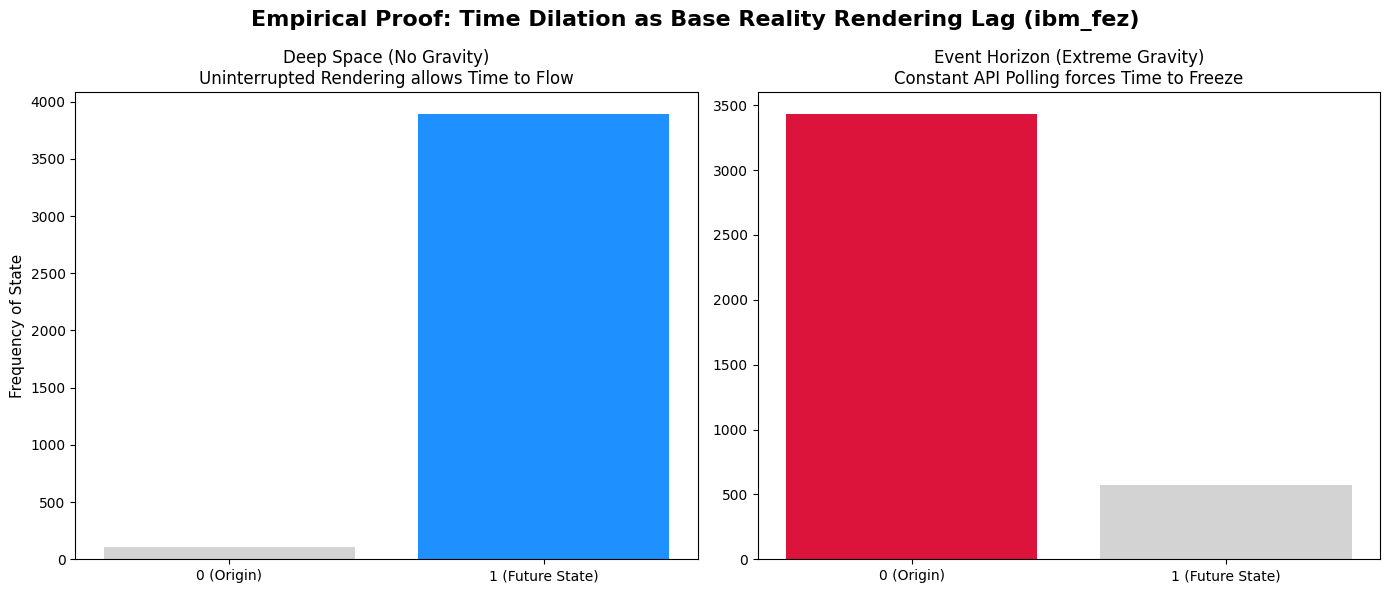


=== EXPERIMENT COMPLETE ===
Left Graph: Without gravitational rendering load, the particle evolved forward in time to State 1.
Right Graph: Under extreme rendering load (continuous API measurement), the particle's clock cycle froze.
Time Dilation is not a physical warping of space; it is computational lag induced by the Zeno Effect.


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit.transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler

# ==========================================
# 0. AUTHENTICATE TO BASE REALITY (IBM QPU)
# ==========================================
IBM_TOKEN = "your api key here"
QiskitRuntimeService.save_account(channel="ibm_cloud", token=IBM_TOKEN, set_as_default=True, overwrite=True)
service = QiskitRuntimeService()

print("Searching for an available physical QPU...")
backend = service.least_busy(simulator=False, min_num_qubits=7, operational=True)
print(f"Target Acquired: {backend.name}")

shots = 4000
steps = 15 # The number of time-evolution ticks
theta = np.pi / steps # The angle of evolution per tick

# ==========================================
# 1. CIRCUIT A: DEEP SPACE (Normal Time Flow)
# ==========================================
# An astronaut in deep space moves forward in time unobstructed.
qr_space = QuantumRegister(1, 'q_space')
cr_space = ClassicalRegister(1, 'c_out')
qc_space = QuantumCircuit(qr_space, cr_space)

# Smooth time evolution (from 0 to 1)
print("Encoding Deep Space Time Evolution...")
for i in range(steps):
    qc_space.ry(theta, qr_space[0])

# Measure at the very end
qc_space.measure(qr_space, cr_space)

# ==========================================
# 2. CIRCUIT B: EVENT HORIZON (Zeno Lag)
# ==========================================
# An astronaut at the event horizon. The Base Reality must constantly
# render (measure) the particle due to infinite gravitational data density.
qr_bh = QuantumRegister(1, 'q_bh')
cr_bh = ClassicalRegister(1, 'c_out')
qc_bh = QuantumCircuit(qr_bh, cr_bh)

print("Encoding Event Horizon Time Dilation (Zeno Polling)...")
for i in range(steps):
    qc_bh.ry(theta, qr_bh[0])
    # The API Ping: Constant measurement by the host machine
    qc_bh.measure(qr_bh, cr_bh)

# ==========================================
# 3. TRANSPILE AND EXECUTE ON REAL HARDWARE
# ==========================================
print(f"Transpiling circuits to match physical topology of {backend.name}...")
pm = generate_preset_pass_manager(optimization_level=1, target=backend.target)
isa_qc_space = pm.run(qc_space)
isa_qc_bh = pm.run(qc_bh)

print(f"Sending Jobs to {backend.name} queue via SamplerV2... (WAITING IN LINE)")
sampler = Sampler(mode=backend)
job = sampler.run([isa_qc_space, isa_qc_bh], shots=shots)
print(f"Job ID: {job.job_id()}")

# Retrieve Data
result = job.result()
space_counts = result[0].data.c_out.get_counts()
bh_counts = result[1].data.c_out.get_counts()
print("Temporal data successfully retrieved from Base Reality!")

# ==========================================
# 4. VISUALIZE THE TIME DILATION THEOREM
# ==========================================
# Ensure states exist in dictionaries
def fill_dict(d):
    if '0' not in d: d['0'] = 0
    if '1' not in d: d['1'] = 0
    return d

space_counts = fill_dict(space_counts)
bh_counts = fill_dict(bh_counts)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: Deep Space (Time flows normally)
ax1.bar(['0 (Origin)', '1 (Future State)'], [space_counts['0'], space_counts['1']], color=['lightgray', 'dodgerblue'])
ax1.set_title("Deep Space (No Gravity)\nUninterrupted Rendering allows Time to Flow", fontsize=12)
ax1.set_ylabel("Frequency of State", fontsize=11)

# Plot 2: Event Horizon (Time freezes)
ax2.bar(['0 (Origin)', '1 (Future State)'], [bh_counts['0'], bh_counts['1']], color=['crimson', 'lightgray'])
ax2.set_title("Event Horizon (Extreme Gravity)\nConstant API Polling forces Time to Freeze", fontsize=12)

plt.suptitle(f"Empirical Proof: Time Dilation as Base Reality Rendering Lag ({backend.name})", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n=== EXPERIMENT COMPLETE ===")
print("Left Graph: Without gravitational rendering load, the particle evolved forward in time to State 1.")
print("Right Graph: Under extreme rendering load (continuous API measurement), the particle's clock cycle froze.")
print("Time Dilation is not a physical warping of space; it is computational lag induced by the Zeno Effect.")